# 03 — Customer segmentation (RFM)
### Olist Brazilian E-Commerce · `retail-platform-analytics`

**RFM** is the classic e-commerce segmentation: score every customer on three axes —
**R**ecency (how recently they bought), **F**requency (how often), and **M**onetary (how much they
spend) — then group them into actionable segments (champions, at-risk, lost, …).

This notebook applies RFM to Olist's `mart_customer_summary`. The interesting twist — and the reason
this is worth doing carefully rather than mechanically — is that **Olist breaks a core RFM
assumption**: almost nobody buys twice. We show that, adapt the method honestly, and build a
segmentation that actually discriminates.

## Data caveats & conventions

- **Grain:** one row per customer, from `mart_customer_summary` (~96k customers).
- **Reference date = 2018-10-17**, the latest order in the dataset. Recency is measured *back from the
  data cutoff*, not from today — this is a historical dataset. So "recency" really means "how late in
  the 2-year window this customer last bought", and a high recency value reflects an early-window
  purchase as much as churn.
- **⚠️ Frequency is near-degenerate.** ~97% of customers have exactly one order (established in `01`).
  The `F` axis therefore barely varies and textbook R×F×M quintile scoring collapses — Section 2 shows
  this explicitly and Section 5 adapts to it. This is the honest, defensible way to run RFM here.
- **`customer_id` resolution** (per-order vs per-person) affects frequency/recency — treat repeat
  behaviour as directional pending confirmation of the dbt mapping.
- Scores are **quintiles** (5 equal-sized buckets); 5 = best (most recent / highest spend).

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

print("Connected:", q("select current_schema() as s").iloc[0, 0])

Connected: DEV_MARTS


## 1. RFM inputs

Pull the three raw RFM measures per customer. **Recency** = days from the customer's last order to the
reference date (dataset max). **Frequency** = number of orders. **Monetary** = total spend.

In [2]:
cust = q('''
    select customer_id,
           total_orders   as frequency,
           total_spend    as monetary,
           avg_review_score,
           is_repeat_customer,
           datediff('day', last_order_at,
                    (select max(last_order_at) from dev_marts.mart_customer_summary)) as recency_days
    from dev_marts.mart_customer_summary
''')
for c in ["frequency", "monetary", "avg_review_score", "recency_days"]:
    cust[c] = pd.to_numeric(cust[c], errors="coerce")
print(f"{len(cust):,} customers")
cust[["recency_days", "frequency", "monetary"]].describe().round(1)

96,096 customers


,recency_days,frequency,monetary
count,"96,096.00","96,096.00","96,096.00"
mean,288.10,1.00,166.60
std,153.40,0.20,231.40
min,0.00,1.00,0.00
25%,164.00,1.00,63.10
50%,269.00,1.00,108.00
75%,397.00,1.00,183.50
max,773.00,17.00,"13,664.10"


## 2. The frequency problem — why textbook RFM doesn't fit Olist

RFM assumes customers repeat, so that Frequency spreads them out. Let's check Olist's frequency
distribution before trusting the `F` axis.

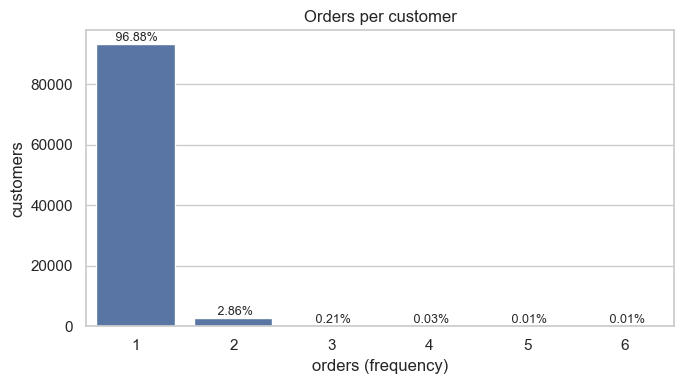

Customers with exactly 1 order: 96.88%


In [3]:
freq = cust["frequency"].value_counts().sort_index()
freq_pct = (100 * freq / freq.sum()).round(2)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=freq.index[:6], y=freq.values[:6], ax=ax, color="#4C72B0")
ax.set_title("Orders per customer"); ax.set_xlabel("orders (frequency)"); ax.set_ylabel("customers")
for i, v in enumerate(freq.values[:6]):
    ax.text(i, v, f" {freq_pct.iloc[i]}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()
print(f"Customers with exactly 1 order: {freq_pct.iloc[0]}%")

**Interpretation.** **~97% of customers have a single order.** Frequency has almost no variance,
so an F-quintile would put nearly everyone in the same bucket — it cannot segment anyone. Forcing a
textbook R×F×M model here would be misleading. **We therefore drop F as a scoring axis and keep it as
a binary "repeat customer" flag**, and build the segmentation on the two axes that *do* vary: Recency
and Monetary. (This is itself a finding: Olist is a one-and-done marketplace — retention, not
frequency-tiering, is the real lever.)

*Is ~3% repeat alarming?* Not for this context. A **discretionary, non-grocery marketplace** (furniture,
electronics, health & beauty) over a two-year window will naturally see low repurchase — high repeat is a
consumables/grocery pattern. The number is low but not anomalous.

## 3. The axes that do vary — Recency & Monetary

Both are usable. Monetary is heavily right-skewed (a few big spenders), so we view it on a clipped
axis.

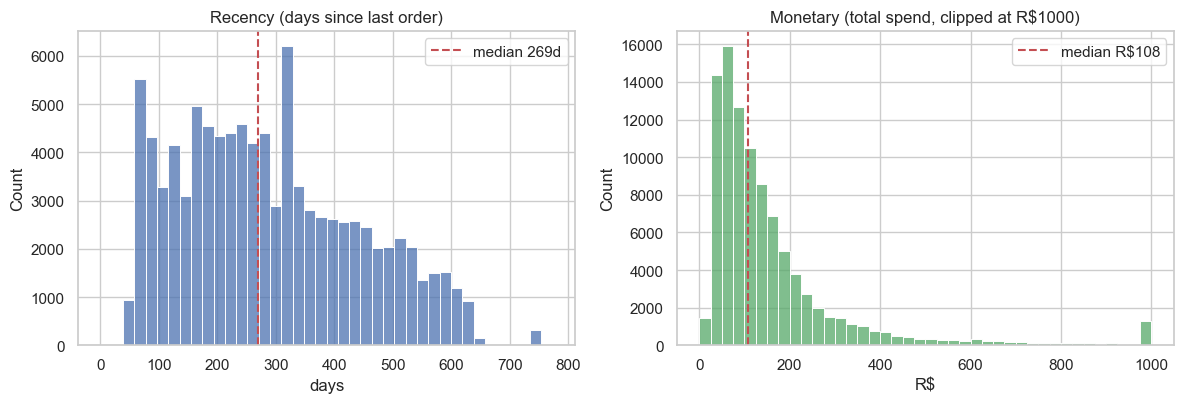

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(cust["recency_days"], bins=40, color="#4C72B0", ax=ax1)
ax1.axvline(cust["recency_days"].median(), color="#C44E52", ls="--",
            label=f"median {cust['recency_days'].median():.0f}d")
ax1.set_title("Recency (days since last order)"); ax1.set_xlabel("days"); ax1.legend()

sns.histplot(cust["monetary"].clip(upper=1000), bins=40, color="#55A868", ax=ax2)
ax2.axvline(cust["monetary"].median(), color="#C44E52", ls="--",
            label=f"median R${cust['monetary'].median():.0f}")
ax2.set_title("Monetary (total spend, clipped at R$1000)"); ax2.set_xlabel("R$"); ax2.legend()
plt.tight_layout(); plt.show()

**Interpretation.** Recency spreads customers evenly across the 2-year window (median ~269 days).
Monetary is right-skewed: most customers spend ~R$100–200, with a thin tail of high-value buyers up to
R$13k. Both axes discriminate well — good raw material for scoring.

## 4. Scoring — Recency & Monetary quintiles

Each customer gets an **R score** and **M score** from 1–5 (quintiles: 5 equal-sized groups).
5 = best (most recent buyer / highest spender), 1 = worst. We rank before binning so the five buckets
are exactly equal even with tied values.

In [5]:
# Rank first so qcut yields exactly 5 equal bins despite ties.
cust["r_score"] = pd.qcut(cust["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
cust["m_score"] = pd.qcut(cust["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

print("R score = 5 means most recent; M score = 5 means highest spend.")
cust.groupby("r_score", observed=True)["recency_days"].agg(["min", "max", "count"])

R score = 5 means most recent; M score = 5 means highest spend.


,min,max,count
r_score,,,
1,433,773,19219
2,318,433,19219
3,227,318,19219
4,142,227,19219
5,0,142,19220


## 5. Segmentation — a Recency × Monetary grid

With F removed, we map the 5×5 R–M grid to a handful of named, actionable segments. First the raw grid
(how customers distribute across R and M), then the segment assignment.

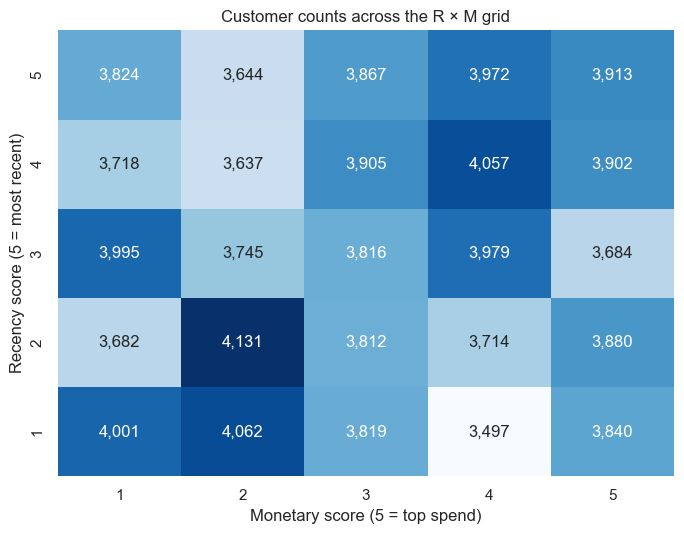

In [6]:
grid = pd.crosstab(cust["r_score"], cust["m_score"])
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(grid.sort_index(ascending=False), annot=True, fmt=",d", cmap="Blues", ax=ax, cbar=False)
ax.set_title("Customer counts across the R × M grid")
ax.set_xlabel("Monetary score (5 = top spend)"); ax.set_ylabel("Recency score (5 = most recent)")
plt.tight_layout(); plt.show()

In [7]:
# Names describe position on the two axes only (recency of the usually-only order x spend tier).
# No loyalty/frequency label is used, because ~97% of customers buy exactly once (Section 2).
def segment(r, m):
    if r >= 4 and m >= 4: return "Top-spend, recent"   # recent order, large basket
    if r >= 4 and m <= 3: return "Low-spend, recent"    # recent order, smaller basket
    if r <= 2 and m >= 4: return "Top-spend, older"     # large basket, but a while ago
    if r <= 2 and m <= 2: return "Low-spend, older"     # small basket, long ago
    return "Mid-tier"

cust["segment"] = [segment(r, m) for r, m in zip(cust["r_score"], cust["m_score"])]
order = ["Top-spend, recent", "Low-spend, recent", "Mid-tier", "Top-spend, older", "Low-spend, older"]
cust["segment"] = pd.Categorical(cust["segment"], categories=order, ordered=True)
cust["segment"].value_counts().reindex(order)

segment
Top-spend, recent    15844
Low-spend, recent    22595
Mid-tier             26850
Top-spend, older     14931
Low-spend, older     15876
Name: count, dtype: int64

**Segment names describe the two axes only** — *recency* of the customer's (usually only) order
× *spend* tier. Because the frequency/loyalty axis was dropped (§2), these are **not** loyalty tiers:
- **Top-spend, recent** (R≥4, M≥4) — bought recently, large basket. Highest current value.
- **Low-spend, recent** (R≥4, M≤3) — bought recently, smaller basket.
- **Top-spend, older** (R≤2, M≥4) — large basket, but the purchase was a while ago → reactivation targets.
- **Low-spend, older** (R≤2, M≤2) — small basket, long ago → lowest priority.
- **Mid-tier** — everyone in between.

## 6. Segment profiles — who they are and what they're worth

Size is not value. Profile each segment by count, average spend, average recency, **share of total
revenue**, and satisfaction, so the segments can be prioritised.

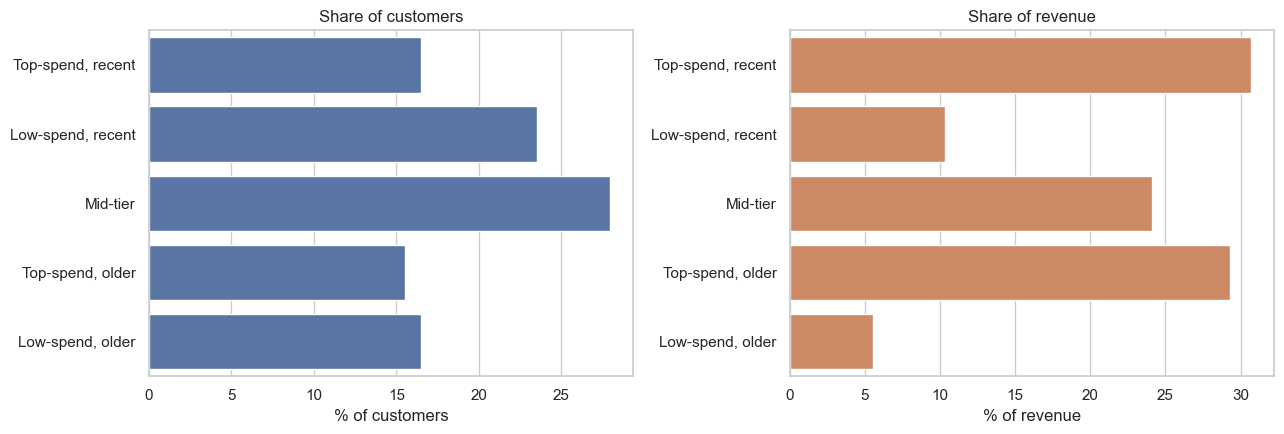

,customers,cust_share_pct,avg_spend,avg_recency_days,revenue_share_pct,repeat_rate_pct,avg_review
segment,,,,,,,
"Top-spend, recent",15844,16.50,310.10,140.80,30.70,6.70,4.10
"Low-spend, recent",22595,23.50,73.40,139.00,10.40,1.10,4.20
Mid-tier,26850,27.90,143.70,319.80,24.10,3.00,4.00
"Top-spend, older",14931,15.50,314.40,444.60,29.30,5.30,4.00
"Low-spend, older",15876,16.50,55.90,446.70,5.50,0.60,4.10


In [8]:
profile = cust.groupby("segment", observed=True).agg(
    customers=("customer_id", "size"),
    avg_spend=("monetary", "mean"),
    avg_recency_days=("recency_days", "mean"),
    total_revenue=("monetary", "sum"),
    repeat_rate_pct=("is_repeat_customer", lambda s: 100 * s.astype(bool).mean()),
    avg_review=("avg_review_score", "mean")).reindex(order)
profile["cust_share_pct"] = 100 * profile["customers"] / profile["customers"].sum()
profile["revenue_share_pct"] = 100 * profile["total_revenue"] / profile["total_revenue"].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
p = profile.reset_index()
sns.barplot(data=p, y="segment", x="cust_share_pct", ax=ax1, color="#4C72B0")
ax1.set_title("Share of customers"); ax1.set_xlabel("% of customers"); ax1.set_ylabel("")
sns.barplot(data=p, y="segment", x="revenue_share_pct", ax=ax2, color="#DD8452")
ax2.set_title("Share of revenue"); ax2.set_xlabel("% of revenue"); ax2.set_ylabel("")
plt.tight_layout(); plt.show()
profile[["customers", "cust_share_pct", "avg_spend", "avg_recency_days",
         "revenue_share_pct", "repeat_rate_pct", "avg_review"]].round(1)

**Interpretation.** The value is lopsided: **Top-spend, recent** is a small slice of customers but
a disproportionate slice of revenue (high M by construction, and recent), while **Low-spend, older** is
the mirror image — many customers, little revenue. **Top-spend, older** is the segment to act on:
meaningful revenue sitting behind customers whose (large) purchase was a while ago.

The `repeat_rate_pct` column above resolves the apparent paradox of a high-value segment on a ~3%-repeat
platform: **even *Top-spend, recent* customers are ~93% one-time buyers (≈6.7% repeat)** — their revenue
share comes from *recent activity + large single-order baskets*, not loyalty. Repeat rate does climb with
segment value (from ~0.6% in *Low-spend, older* to ~6.7% in *Top-spend, recent*) but never clears 7%. So
these segments are about *acquisition timing and basket size* — Olist's growth lever is **acquisition +
reactivation**, not loyalty/frequency tiering.

## 7. Findings & recommendations

### What we found
1. **RFM's frequency axis doesn't apply** — ~97% single-order customers. We adapted to a Recency ×
   Monetary segmentation with a repeat flag, which is the honest way to segment this dataset.
2. **Revenue is concentrated in the top-spend segments** while the customer *count* is dominated by
   low-spend, older buyers.
3. **"Top-spend, older" is the actionable pocket** — real revenue behind customers whose large purchase
   was a while ago.

### Recommendations (if live)
- **Reactivation over loyalty-tiering** — target *Top-spend, older* with win-back offers; there's no
  frequency ladder to climb here, so the lever is bringing one-time buyers back at all.
- **Grow the basket of Low-spend, recent** customers early, while recency is high.
- **Don't over-invest in Low-spend, older** — large but low-yield.

### Backlog update
- `04_category_and_freight_economics.ipynb` — freight-as-margin-proxy *by category and weight*
  (deepening `01`'s overall trend), plus category price/freight economics.
- Optional `00_executive_summary.ipynb` — stakeholder rollup once the deep-dives are done.